In [3]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit, prange
from scipy.optimize import differential_evolution

### Formula used in **gravity3d.py** module :
The vertical gravitational effect $g_z$ at an observation point $(x_o, y_o, z_o)$ due to a rectangular prism using the following expression:

\begin{equation}
g_z = G \cdot \Delta \rho \cdot \sum_{i=1}^{2} \sum_{j=1}^{2} \sum_{k=1}^{2} (-1)^{i+j+k} \cdot \arctan\left( \frac{(x_i - x_o)(y_j - y_o)}{(z_k - z_o)\sqrt{(x_i - x_o)^2 + (y_j - y_o)^2 + (z_k - z_o)^2}} \right)
\end{equation}
**Where:**

- $ x_i \in \{x_1, x_2\},\quad y_j \in \{y_1, y_2\},\quad z_k \in \{z_1, z_2\}$
- $\Delta \rho $: Density contrast of the prism
- $ G $: Gravitational constant
- $ R = \sqrt{(x_i - x_o)^2 + (y_j - y_o)^2 + (z_k - z_o)^2}$





The output is converted to milligals (mGal) using:
$
G_{\text{mGal}} = G \times 10^5
$


This implementation includes only the arctangent term from the full Nagy formula and omits the logarithmic terms. The complete expression for the gravitational attraction from Nagy (1966) is:

\begin{equation}
f(x, y, z) = x \ln(y + R) + y \ln(x + R) - z \arctan \left( \frac{xy}{zR} \right)
\end{equation}

Thus, the current implementation captures the general shape of the gravity anomaly but is an approximation used for computational speed.


- The code uses a simplified form of Nagy’s prism gravity formula.
- It is computationally efficient and suitable for large forward models.




#### Adding random noise :

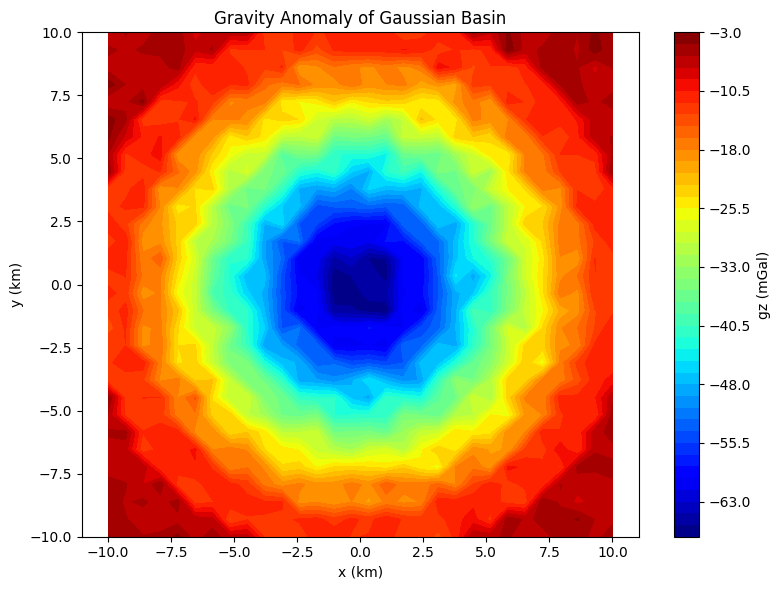

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from gauss_fft_general3d import gauss_fft_gravity_3d

# ---------------------------
# 1. Grid Parameters
# ---------------------------
nx, ny, nz = 30,30,15
Lx, Ly, Lz = 20e3, 20e3, 4e3  # in meters

x = np.linspace(-Lx/2, Lx/2, nx)
y = np.linspace(-Ly/2, Ly/2, ny)
z = np.linspace(0, Lz, nz)  # top to bottom depth
dx, dy, dz = x[1] - x[0], y[1] - y[0], z[1] - z[0]

X, Y = np.meshgrid(x, y, indexing='ij')
Zc = z + dz/2  # cell-centered depths

# ---------------------------
# 2. Define Gaussian Basin
# ---------------------------
depth_max = 3000  # meters
x0, y0 = 0.0, 0.0
sigma_x, sigma_y = 5e3, 5e3

# Basin depth surface z(x,y)
Z_basin = depth_max * np.exp(-((X - x0)**2 / (2 * sigma_x**2) + (Y - y0)**2 / (2 * sigma_y**2)))

# ---------------------------
# 3. Create Density Model
# ---------------------------
rho_model = np.zeros((nx, ny, nz))
density_contrast = -500  # in kg/m³

for k in range(nz):
    mask = z[k] < Z_basin  # inside basin
    rho_model[:, :, k][mask] = density_contrast

# ---------------------------
# 4. Compute Gravity Anomaly
# ---------------------------
gz = gauss_fft_gravity_3d(dx, dy, dz, Zc, rho_model, z0=0.0)
noise_std = 1  # mGal
#np.random.seed(42)
gz+= np.random.normal(0, noise_std, gz.shape)

# ---------------------------
# 5. Plot Results
# ---------------------------
plt.figure(figsize=(8, 6))
plt.contourf(x/1000, y/1000, gz.T, levels=50, cmap="jet")
plt.colorbar(label="gz (mGal)")
plt.xlabel("x (km)")
plt.ylabel("y (km)")
plt.title("Gravity Anomaly of Gaussian Basin")
plt.axis("equal")
plt.tight_layout()
plt.show()


🔄 Running DE global inversion...
differential_evolution step 1: f(x)= 184.18965952634662
differential_evolution step 2: f(x)= 169.42820052762056
differential_evolution step 3: f(x)= 143.4027395909799
differential_evolution step 4: f(x)= 120.19015234961611
differential_evolution step 5: f(x)= 101.72604660389818
differential_evolution step 6: f(x)= 86.45226365397791
differential_evolution step 7: f(x)= 73.28466001730632
differential_evolution step 8: f(x)= 54.4319609098832
differential_evolution step 9: f(x)= 50.16192118869789
differential_evolution step 10: f(x)= 41.49771619876191
differential_evolution step 11: f(x)= 41.49771619876191
differential_evolution step 12: f(x)= 41.49771619876191
differential_evolution step 13: f(x)= 41.49771619876191
differential_evolution step 14: f(x)= 41.49771619876191
differential_evolution step 15: f(x)= 33.97230198298192
differential_evolution step 16: f(x)= 26.091415467953976
differential_evolution step 17: f(x)= 26.091415467953976
differential_evolut

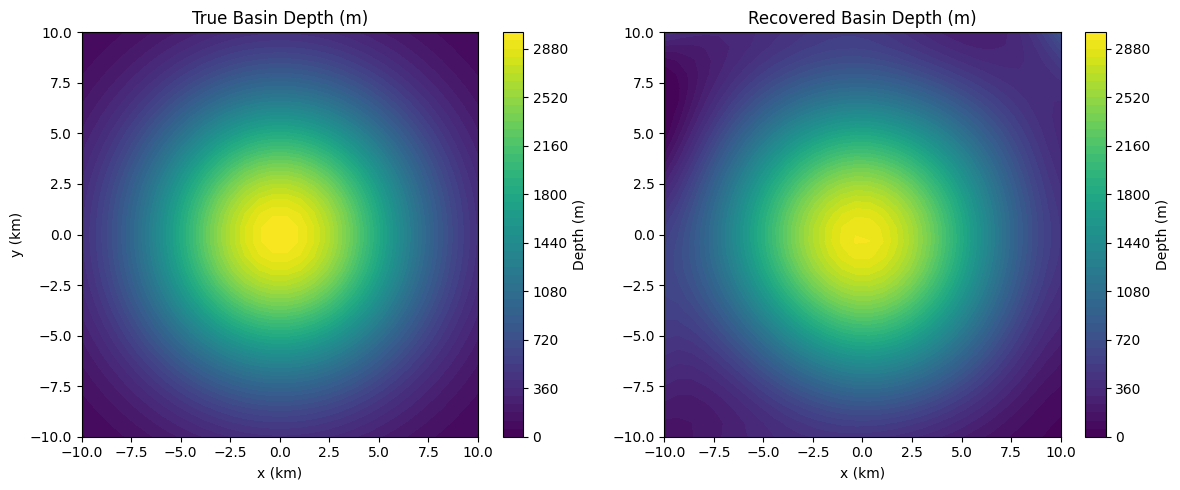

In [3]:
from scipy.interpolate import RectBivariateSpline
from scipy.optimize import differential_evolution

# ---------------------------
# 6. Control Grid Setup
# ---------------------------
n_ctrl_x, n_ctrl_y = 5,5
x_ctrl = np.linspace(x.min(), x.max(), n_ctrl_x)
y_ctrl = np.linspace(y.min(), y.max(), n_ctrl_y)
max_depth = depth_max  # same as used for true basin

def surface_from_params(params):
    ctrl_depths = params.reshape((n_ctrl_x, n_ctrl_y))
    spline = RectBivariateSpline(x_ctrl, y_ctrl, ctrl_depths, kx=3, ky=3)
    return np.clip(spline(x, y, grid=True), 0, max_depth)

# ---------------------------
# 7. Density Builder
# ---------------------------
def build_density_model(depth_surface, zc):
    rho = np.zeros((nx, ny, nz))
    for k in range(nz):
        mask = z[k] < depth_surface
        rho[:, :, k][mask] = density_contrast
    return rho

# ---------------------------
# 8. Misfit Function
# ---------------------------
gz_obs = gz.copy()  # use synthetic data as observation

def misfit(params):
    basin_depth = surface_from_params(params)
    rho_model_est = build_density_model(basin_depth, Zc)
    gz_pred = gauss_fft_gravity_3d(dx, dy, dz, Zc, rho_model_est)
    return np.mean((gz_pred.T - gz_obs.T) ** 2)

# ---------------------------
# 9. Run Differential Evolution
# ---------------------------
bounds = [(0, max_depth)] * (n_ctrl_x * n_ctrl_y)
print("🔄 Running DE global inversion...")
result = differential_evolution(
    misfit, bounds, strategy='best1bin',
    maxiter=50, popsize=10, tol=1e-5,
    polish=False, disp=True
)
best_params = result.x
recovered_surface = surface_from_params(best_params)

# ---------------------------
# 10. Plot True vs Recovered
# ---------------------------
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.title("True Basin Depth (m)")
plt.contourf(x/1000, y/1000, Z_basin.T, levels=50, cmap="viridis")
plt.xlabel("x (km)")
plt.ylabel("y (km)")
plt.colorbar(label="Depth (m)")

plt.subplot(1, 2, 2)
plt.title("Recovered Basin Depth (m)")
plt.contourf(x/1000, y/1000, recovered_surface.T, levels=50, cmap="viridis")
plt.xlabel("x (km)")
plt.colorbar(label="Depth (m)")

plt.tight_layout()
plt.show()


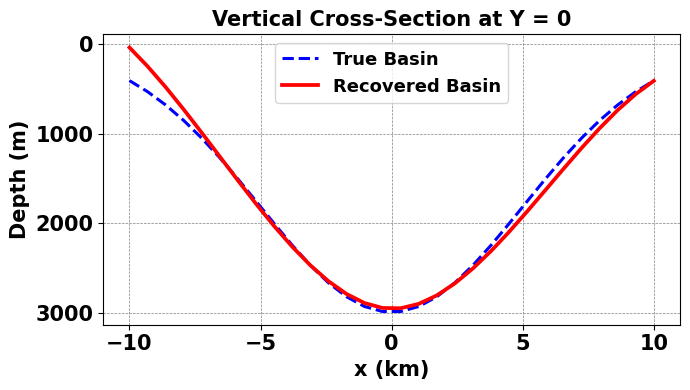

In [4]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# ---------------------------
# 11. Cross-section Comparison (Vertical Middle)
# ---------------------------
mid_j = ny // 2  # middle index along y-direction
x_km = x / 1000

true_section = Z_basin[:, mid_j]
recovered_section = recovered_surface[:, mid_j]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x_km, true_section, label="True Basin", linestyle='--', color="blue", linewidth=2.2)
ax.plot(x_km, recovered_section, color='red', label="Recovered Basin", linewidth=2.7)

# Labels and Title
ax.set_xlabel("x (km)", fontweight='bold', fontsize=15)
ax.set_ylabel("Depth (m)", fontweight='bold', fontsize=15)
ax.set_title("Vertical Cross-Section at Y = 0", fontweight='bold', fontsize=15)

# Bold tick labels
ax.tick_params(axis='both', labelsize=15)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')

# Fixed grid tick spacing
tick_spacing_km = 5      # 5 km in x
tick_spacing_m = 1000    # 1000 m in depth
ax.xaxis.set_major_locator(MultipleLocator(tick_spacing_km))
ax.yaxis.set_major_locator(MultipleLocator(tick_spacing_m))

# Grid + reverse Y (depth)
ax.grid(True, linestyle='--', color='gray', linewidth=0.5)
ax.invert_yaxis()
ax.legend(prop={'weight': 'bold', 'size':13 })

plt.tight_layout()
plt.show()


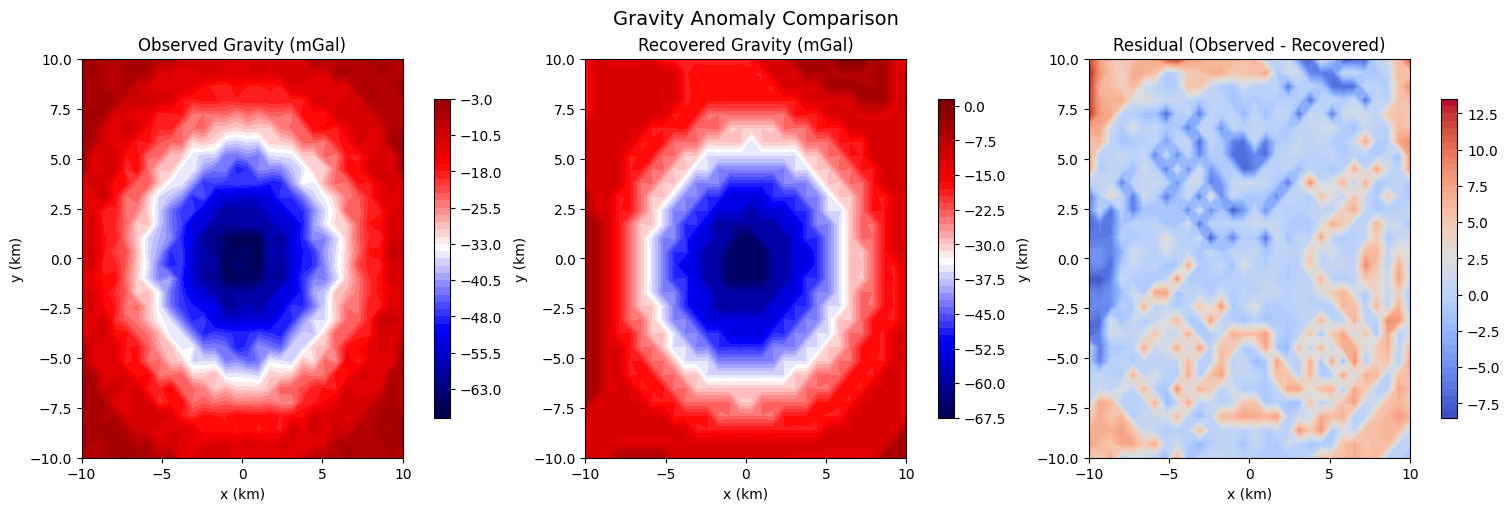

In [9]:
# ---------------------------
# 12. Plot Observed, Predicted, and Residual Gravity
# ---------------------------

# Compute gravity from recovered model
rho_recovered = build_density_model(recovered_surface, Zc)
gz_pred = gauss_fft_gravity_3d(dx, dy, dz, Zc, rho_recovered)

residual = gz_obs - gz_pred

vmin = np.min([gz_obs.min(), gz_pred.min()])
vmax = np.max([gz_obs.max(), gz_pred.max()])

fig, axs = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

im0 = axs[0].contourf(x/1000, y/1000, gz_obs.T, levels=50, cmap='seismic', vmin=vmin, vmax=vmax)
axs[0].set_title("Observed Gravity (mGal)")
axs[0].set_xlabel("x (km)")
axs[0].set_ylabel("y (km)")
fig.colorbar(im0, ax=axs[0], shrink=0.8)

im1 = axs[1].contourf(x/1000, y/1000, gz_pred.T, levels=50, cmap='seismic', vmin=vmin, vmax=vmax)
axs[1].set_title("Recovered Gravity (mGal)")
axs[1].set_xlabel("x (km)")
axs[1].set_ylabel("y (km)")
fig.colorbar(im1, ax=axs[1], shrink=0.8)

im2 = axs[2].contourf(x/1000, y/1000, residual.T, levels=50, cmap='coolwarm')
axs[2].set_title("Residual (Observed - Recovered)")
axs[2].set_xlabel("x (km)")
axs[2].set_ylabel("y (km)")
fig.colorbar(im2, ax=axs[2], shrink=0.8)

plt.suptitle("Gravity Anomaly Comparison", fontsize=14)
plt.show()


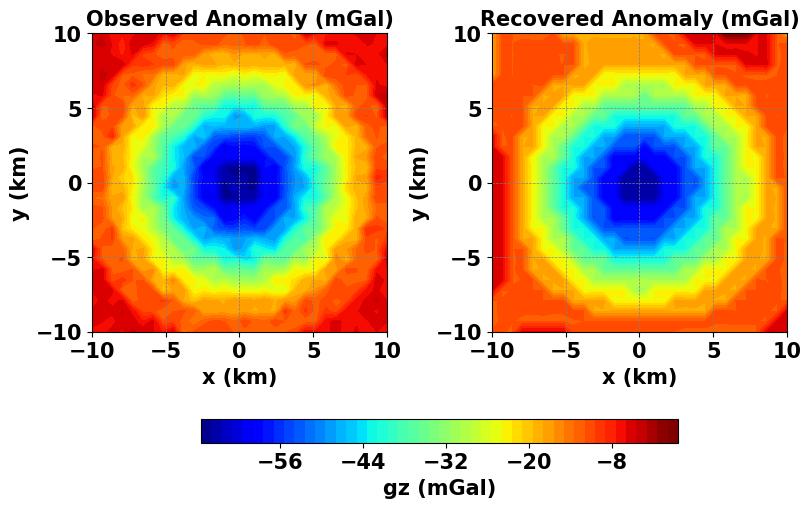

In [25]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import numpy as np

# --- Prepare values ---
vmin = np.min([gz_obs.min(), gz_pred.min()])
vmax = np.max([gz_obs.max(), gz_pred.max()])
tick_spacing_km = 5
cbar_ticks = np.arange(np.floor(vmin), np.ceil(vmax) + 1,12)

fig, axs = plt.subplots(1, 2, figsize=(8, 5), constrained_layout=True)

titles = ["Observed Anomaly (mGal)", "Recovered Anomaly (mGal)"]
data = [gz_obs.T, gz_pred.T]

for i in range(2):
    im = axs[i].contourf(x/1000, y/1000, data[i], levels=50, cmap='jet', vmin=vmin, vmax=vmax)
    axs[i].set_title(titles[i], fontweight='bold', fontsize=15)
    axs[i].set_xlabel("x (km)", fontweight='bold', fontsize=15)
    axs[i].set_ylabel("y (km)", fontweight='bold', fontsize=15)
    axs[i].xaxis.set_major_locator(MultipleLocator(tick_spacing_km))
    axs[i].yaxis.set_major_locator(MultipleLocator(tick_spacing_km))
    axs[i].grid(True, linestyle='--', color='gray', linewidth=0.5)
    axs[i].tick_params(axis='both', labelsize=15)
    for label in axs[i].get_xticklabels() + axs[i].get_yticklabels():
        label.set_fontweight('bold')

# --- Shared horizontal colorbar ---
cbar = fig.colorbar(im, ax=axs, orientation='horizontal',
                    fraction=0.08, pad=0.1, ticks=cbar_ticks)

cbar.set_label("gz (mGal)", fontweight='bold', fontsize=15)
cbar.ax.tick_params(labelsize=15)
for label in cbar.ax.get_xticklabels():
    label.set_fontweight('bold')

plt.show()


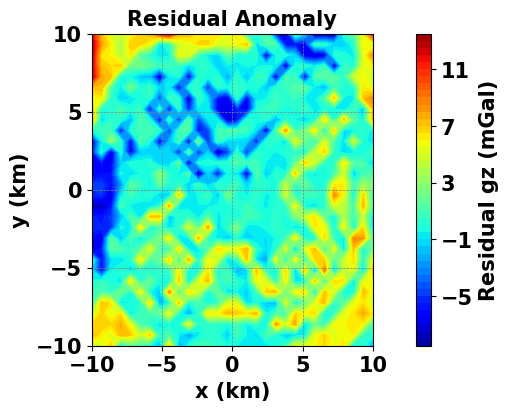

In [29]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import numpy as np

# --- Compute Residual ---
residual = gz_obs - gz_pred
res_min = np.floor(residual.min())
res_max = np.ceil(residual.max())
res_ticks = np.arange(res_min, res_max + 1,4)

fig, ax = plt.subplots(figsize=(5,4), constrained_layout=True)

# --- Residual Plot ---
im = ax.contourf(x/1000, y/1000, residual.T, levels=50, cmap='jet', vmin=res_min, vmax=res_max)
ax.set_title("Residual Anomaly", fontweight='bold', fontsize=15)
ax.set_xlabel("x (km)", fontweight='bold', fontsize=15)
ax.set_ylabel("y (km)", fontweight='bold', fontsize=15)
ax.xaxis.set_major_locator(MultipleLocator(5))
ax.yaxis.set_major_locator(MultipleLocator(5))
ax.grid(True, linestyle='--', color='gray', linewidth=0.5)
ax.tick_params(axis='both', labelsize=15)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')

# --- Horizontal Colorbar ---
cbar = fig.colorbar(im, ax=ax, orientation='vertical', fraction=0.1, pad=0.1, ticks=res_ticks)
cbar.set_label("Residual gz (mGal)", fontweight='bold', fontsize=15)
cbar.ax.tick_params(labelsize=15)
for label in cbar.ax.get_yticklabels():  # for vertical colorbar
    label.set_fontweight('bold')


plt.show()
